<a href="https://colab.research.google.com/github/Samrandd/Portfolio/blob/master/ny-cfpb-complaint-intelligence/notebooks/NY_Financial_Complaint_Intelligence_DistilBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    set_seed,
    Trainer,
    pipeline
)

**Business question:**

How can a financial-services team use customer complaint narratives to route issues faster, detect emerging problems, and prioritize CX, Product, Operations, or Compliance action?




| Step | What we do                                                                           | What goes in the final project |
| ---- | ------------------------------------------------------------------------------------ | ------------------------------ |
| 1    | Load real NY complaint narratives from CFPB                                          | Data source and project scope  |
| 2    | Audit missing data, duplicates, dates, products, issues, and narrative length        | Data-quality section           |
| 3    | Define the prediction target: a manageable set of high-volume complaint issue groups | Clear business use case        |
| 4    | Analyze NY complaint trends by product, issue, company response, and time            | Insight charts                 |
| 5    | Build a time-based, leakage-safe train/validation/test split                         | Credible evaluation design     |
| 6    | Train a TF-IDF + Logistic Regression baseline                                        | Benchmark model                |
| 7    | Fine-tune DistilBERT and compare it with the baseline                                | Main NLP model                 |
| 8    | Review errors, confidence, and ambiguous complaints                                  | Practical model limitations    |
| 9    | Build an “early-warning” view showing rising complaint themes                        | Business-facing output         |
| 10   | Test new complaint narratives through an inference function                          | Working demo                   |
| 11   | Create the GitHub README, polished charts, Medium article, and LinkedIn post         | Publication package            |


STEP1: Pull the data

In [2]:
!wget -q --show-progress \
https://files.consumerfinance.gov/ccdb/complaints.csv.zip \
-O complaints.csv.zip

!ls -lh complaints.csv.zip

complaints.csv.zip  100%[===================>]   1.32G  8.33MB/s    in 2m 48s  
-rw-r--r-- 1 root root 1.4G Aug 22 09:21 complaints.csv.zip


STEP 2: Create our clean New York working dataset

In [3]:
import pandas as pd

keep_columns = [
    "Complaint ID",
    "Date received",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company",
    "State",
    "ZIP code",
    "Submitted via",
    "Company response to consumer",
    "Timely response?"
]

ny_complaints = []

for chunk in pd.read_csv(
    "complaints.csv.zip",
    compression="zip",
    usecols=keep_columns,
    chunksize=100_000,
    low_memory=False
):
    chunk["Date received"] = pd.to_datetime(
        chunk["Date received"],
        errors="coerce"
    )

    ny_chunk = chunk[
        (chunk["State"] == "NY") &
        (chunk["Date received"] >= "2024-01-01") &
        (chunk["Date received"] < "2026-01-01") &
        (chunk["Consumer complaint narrative"].notna())
    ]

    ny_complaints.append(ny_chunk)

complaints_df = pd.concat(ny_complaints, ignore_index=True)

print("New York complaint dataset shape:", complaints_df.shape)
print("Date range:", complaints_df["Date received"].min(), "to", complaints_df["Date received"].max())

display(complaints_df.head())

New York complaint dataset shape: (114025, 13)
Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Complaint ID
0,2025-12-02,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",My consolidation on my student loans was in XX...,MOHELA,NY,14701,Web,Closed with explanation,No,18041659
1,2025-06-13,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Received bad information about your loan,On XX/XX/XXXX and again on XX/XX/XXXX I notifi...,MOHELA,NY,136XX,Web,Closed with explanation,No,14064409
2,2025-12-01,Credit card,Store credit card,Fees or interest,Charged too much interest,"In approximately XX/XX/XXXX, I opened a XXXXXX...","Imprint Payments, Inc.",NY,10036,Web,Closed with explanation,No,21948568
3,2025-12-01,Debt collection,Other debt,Attempts to collect debt not owed,Debt is not yours,This account was made without my consent back ...,LJ Ross Associates,NY,14616,Web,Closed with explanation,Yes,18074328
4,2025-06-06,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Problem with customer service,My loans were forgiven under PSLF in XXXX. I w...,MOHELA,NY,11218,Web,Closed with explanation,No,13939334


114,025 NY complaints, all with narratives, from 2024–2025

STEP 3 — Quick data audit

In [4]:
# STEP 3 — Quick data audit

print("Total complaints:", len(complaints_df))
print("Duplicate complaint IDs:", complaints_df["Complaint ID"].duplicated().sum())

print("\nMissing values:")
display(
    complaints_df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("Missing values")
)

print("\nMost common products:")
display(
    complaints_df["Product"]
    .value_counts()
    .head(15)
    .to_frame("Complaints")
)
print("\nMost common products (normalized):")
display(
    complaints_df["Product"]
    .value_counts(normalize=True)
    .head(15)
    .mul(100).round(2)
    .to_frame("Complaints")
)

# Removed redundant 'Most common issues' display. The normalized version follows.

print("\nMost common issues (normalized):")
display(
    complaints_df["Issue"]
    .value_counts(normalize=True)
    .head(20)
    .mul(100).round(2)
    .to_frame("Complaints (%)")
)
complaints_df["narrative_length"] = (
    complaints_df["Consumer complaint narrative"].str.len()
)

print("\nNarrative length:")
display(complaints_df["narrative_length"].describe().to_frame().T)


Total complaints: 114025
Duplicate complaint IDs: 0

Missing values:


,Missing values
Sub-issue,5660
Date received,0
Product,0
Sub-product,0
Issue,0
Consumer complaint narrative,0
Company,0
State,0
ZIP code,0
Submitted via,0



Most common products:


,Complaints
Product,
Credit reporting or other personal consumer reports,85896
Debt collection,7839
Checking or savings account,5860
Credit card,5551
"Money transfer, virtual currency, or money service",4623
Student loan,1167
Mortgage,1089
Vehicle loan or lease,881
Prepaid card,470



Most common products (normalized):


,Complaints
Product,
Credit reporting or other personal consumer reports,75.33
Debt collection,6.87
Checking or savings account,5.14
Credit card,4.87
"Money transfer, virtual currency, or money service",4.05
Student loan,1.02
Mortgage,0.96
Vehicle loan or lease,0.77
Prepaid card,0.41



Most common issues (normalized):


,Complaints (%)
Issue,
Incorrect information on your report,42.38
Improper use of your report,20.51
Problem with a company's investigation into an existing problem,12.27
Attempts to collect debt not owed,3.47
Managing an account,2.92
Other transaction problem,2.50
Written notification about debt,1.65
Problem with a purchase shown on your statement,1.44
Closing an account,0.82



Narrative length:


,count,mean,std,min,25%,50%,75%,max
narrative_length,114025.0,987.849287,1195.408312,10.0,345.0,657.0,1218.0,32746.0


Insight: This is a strong real-world dataset. The only missing field is Sub-issue (5,660 rows); we can keep it for analysis, but won’t rely on it for the model.

One important finding: the data is very imbalanced. Credit-reporting complaints alone make up about 75% of records, so later we will use macro F1, not accuracy, to judge the model.

In [7]:
# Dashboard data export
# Use the full NY dataset for real complaint-volume insights,
# not the de-duplicated dataset created for model training.
dashboard_df = complaints_df.copy()

dashboard_df["Date received"] = pd.to_datetime(
    dashboard_df["Date received"]
)

dashboard_df["Month"] = dashboard_df["Date received"].dt.to_period("M").astype(str)

monthly_summary = (
    dashboard_df.groupby(
        [
            "Month",
            "Product",
            "Issue",
            "Submitted via",
            "Company response to consumer",
            "Timely response?"
        ]
    )
    .size()
    .reset_index(name="Complaints")
)

monthly_summary.to_csv("monthly_complaint_summary.csv", index=False)

print("Dashboard file created.")
print("Rows:", len(monthly_summary))

monthly_summary.head()




Dashboard file created.
Rows: 3497


,Month,Product,Issue,Submitted via,Company response to consumer,Timely response?,Complaints
0,2024-01,Checking or savings account,Closing an account,Web,Closed with explanation,Yes,21
1,2024-01,Checking or savings account,Closing an account,Web,Closed with monetary relief,Yes,3
2,2024-01,Checking or savings account,Closing an account,Web,Closed with non-monetary relief,Yes,5
3,2024-01,Checking or savings account,Incorrect information on your report,Web,Closed with explanation,Yes,1
4,2024-01,Checking or savings account,Managing an account,Web,Closed with explanation,Yes,67


In [8]:
from google.colab import files
files.download("monthly_complaint_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
daily_summary = (
    dashboard_df.groupby(
        [
            "Date received",
            "Product",
            "Issue",
            "Submitted via",
            "Company response to consumer",
            "Timely response?"
        ]
    )
    .size()
    .reset_index(name="Complaints")
)

daily_summary.to_csv("daily_complaint_summary.csv", index=False)
files.download("daily_complaint_summary.csv")

print("Daily dashboard file created.")
print("Rows:", len(daily_summary))

daily_summary.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Daily dashboard file created.
Rows: 20617


,Date received,Product,Issue,Submitted via,Company response to consumer,Timely response?,Complaints
0,2024-01-01,Checking or savings account,Managing an account,Web,Closed with explanation,Yes,1
1,2024-01-01,Credit card,"Advertising and marketing, including promotion...",Web,Closed with explanation,Yes,1
2,2024-01-01,Credit reporting or other personal consumer re...,Improper use of your report,Web,Closed with explanation,Yes,3
3,2024-01-01,Credit reporting or other personal consumer re...,Improper use of your report,Web,Closed with non-monetary relief,Yes,5
4,2024-01-01,Credit reporting or other personal consumer re...,Incorrect information on your report,Web,Closed with explanation,Yes,7


STEP 5 — Create the modeling dataset

Let’s make the model’s job clear: predict the complaint issue from the customer’s narrative.

We’ll keep only issue labels with at least 500 examples. That is enough data for each class after the time-based train/test split; rare issues are too inconsistent for a first routing model.

In [5]:
main_complaints_per_issue=500
issue_counts=complaints_df["Issue"].value_counts()
selected_issues=issue_counts[
    issue_counts >= main_complaints_per_issue
].index

model_df=complaints_df[
    complaints_df["Issue"].isin(selected_issues)
].copy()

print("Issue labels included:", model_df["Issue"].nunique())
print("Records included:", len(model_df))
print("Records excluded:", len(complaints_df) - len(model_df))

display(
    model_df["Issue"]
    .value_counts(normalize=True)
    .mul(100).round(2)
    .to_frame("Complaints")
)


Issue labels included: 18
Records included: 106522
Records excluded: 7503


,Complaints
Issue,
Incorrect information on your report,45.37
Improper use of your report,21.96
Problem with a company's investigation into an existing problem,13.13
Attempts to collect debt not owed,3.72
Managing an account,3.12
Other transaction problem,2.68
Written notification about debt,1.77
Problem with a purchase shown on your statement,1.54
Closing an account,0.87


We now have 18 recurring issue labels and 106,522 complaints (93% of the original NY dataset). That is a solid model dataset.

Before splitting it, we need one important check: does the same complaint narrative appear more than once, and does it ever have different issue labels? That could create leakage or conflicting training examples.

STEP 6 — Check duplicate narratives and conflicting labels

In [ ]:
model_df["narrative_clean"] = (
    model_df["Consumer complaint narrative"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True) #find one or more whitespace characters
    .str.strip()
)

duplicate_narratives = model_df.duplicated(
    subset="narrative_clean"
).sum()

conflicting_narratives = (
    model_df.groupby("narrative_clean")["Issue"]
    .nunique()
)

conflicting_narratives = conflicting_narratives[
    conflicting_narratives > 1
]

print("Duplicate narratives:", duplicate_narratives)
print("Narratives assigned to multiple issues:", len(conflicting_narratives))

if len(conflicting_narratives) > 0:
    conflict_examples = model_df[
        model_df["narrative_clean"].isin(conflicting_narratives.index)
    ][["Consumer complaint narrative", "Issue"]]

    display(conflict_examples.head(10))

Duplicate narratives: 49344
Narratives assigned to multiple issues: 463


,Consumer complaint narrative,Issue
119,I just reviewed my credit reports and it shows...,Problem with a company's investigation into an...
120,I recently checked my credit reports and I fou...,Incorrect information on your report
129,I recently checked my credit reports and I fou...,Incorrect information on your report
130,I recently checked my credit reports and I fou...,Incorrect information on your report
138,I just reviewed my credit reports and it shows...,Incorrect information on your report
139,I just reviewed my credit reports and it shows...,Incorrect information on your report
140,I just reviewed my credit reports and it shows...,Incorrect information on your report
143,I recently checked my credit reports and I fou...,Problem with a company's investigation into an...
151,I just reviewed my credit reports and it shows...,Problem with a company's investigation into an...
152,I just reviewed my credit reports and it shows...,Problem with a company's investigation into an...


Insight:

* 49,344 rows are repeat copies of an earlier narrative.
463 unique narratives were assigned to more than one issue.

A normal random split would let the model see many test narratives during training, which would make results look far better than real-life performance. We’ll fix it now. This keeps the earliest copy of each narrative—so the model never trains on a future version of the same text—and removes narratives with conflicting issue labels.

STEP 7 — Build a leakage-safe dataset

In [ ]:
conflicting_texts = conflicting_narratives.index
leakage_safe_df = model_df[
    ~model_df["narrative_clean"].isin(conflicting_texts)
].copy()

In [ ]:
leakage_safe_df = (
    leakage_safe_df
    .sort_values("Date received")
    .drop_duplicates(subset="narrative_clean", keep="first")
    .copy()
)

In [ ]:
rows_removed_for_conflicts = len(conflict_examples)

print("Rows removed because the same narrative had different issues:",rows_removed_for_conflicts)

print("Rows after keeping one copy of each narrative:",
      len(leakage_safe_df))

print("Unique narratives remaining:",
      leakage_safe_df["narrative_clean"].nunique())

print("\nIssue distribution after cleaning:")
display(
    leakage_safe_df["Issue"]
    .value_counts(normalize=True)
    .to_frame("Complaints")
)

Rows removed because the same narrative had different issues: 21561
Rows after keeping one copy of each narrative: 56715
Unique narratives remaining: 56715

Issue distribution after cleaning:


,Complaints
Issue,
Incorrect information on your report,0.376655
Improper use of your report,0.195098
Problem with a company's investigation into an existing problem,0.123830
Managing an account,0.056881
Attempts to collect debt not owed,0.046161
Problem with a purchase shown on your statement,0.028934
Other transaction problem,0.027224
Written notification about debt,0.021106
Closing an account,0.016363


Insight:
We removed 21,561 rows where the exact same text had conflicting official issues, then kept one copy of every remaining narrative. We have 56,715 unique, consistently labelled complaints left.

Next, we’ll split by time—not randomly:

* Training: 2024
* Validation: January–June 2025
* Test: July–December 2025

That simulates the real use case: train on older complaints and evaluate on future ones.

STEP 8 — Create time-based train, validation, and test datasets

In [ ]:
train_df = leakage_safe_df[
    leakage_safe_df["Date received"] < "2025-01-01"
].copy()

validation_df = leakage_safe_df[
    (leakage_safe_df["Date received"] >= "2025-01-01") &
    (leakage_safe_df["Date received"] < "2025-07-01")
].copy()

test_df = leakage_safe_df[
    leakage_safe_df["Date received"] >= "2025-07-01"
].copy()

In [ ]:
# STEP 8 — Create time-based train, validation, and test datasets

train_df = leakage_safe_df[
    leakage_safe_df["Date received"] < "2025-01-01"
].copy()

validation_df = leakage_safe_df[
    (leakage_safe_df["Date received"] >= "2025-01-01") &
    (leakage_safe_df["Date received"] < "2025-07-01")
].copy()

test_df = leakage_safe_df[
    leakage_safe_df["Date received"] >= "2025-07-01"
].copy()

split_summary = pd.DataFrame([
    {
        "Dataset": "Training",
        "Records": len(train_df),
        "Issue labels": train_df["Issue"].nunique(),
        "Date range": f"{train_df['Date received'].min().date()} to {train_df['Date received'].max().date()}"
    },
    {
        "Dataset": "Validation",
        "Records": len(validation_df),
        "Issue labels": validation_df["Issue"].nunique(),
        "Date range": f"{validation_df['Date received'].min().date()} to {validation_df['Date received'].max().date()}"
    },
    {
        "Dataset": "Test",
        "Records": len(test_df),
        "Issue labels": test_df["Issue"].nunique(),
        "Date range": f"{test_df['Date received'].min().date()} to {test_df['Date received'].max().date()}"
    }
])

display(split_summary)

print(
    "Train and validation narrative overlap:",
    len(set(train_df["narrative_clean"]) & set(validation_df["narrative_clean"]))
)

print(
    "Train and test narrative overlap:",
    len(set(train_df["narrative_clean"]) & set(test_df["narrative_clean"]))
)

,Dataset,Records,Issue labels,Date range
0,Training,26186,18,2024-01-01 to 2024-12-31
1,Validation,17391,18,2025-01-01 to 2025-06-30
2,Test,13138,18,2025-07-01 to 2025-12-31


Train and validation narrative overlap: 0
Train and test narrative overlap: 0


All 18 issue labels appear in every split, and there is zero text overlap. This is a proper future-facing evaluation setup.

Next, we’ll build a simple baseline before DistilBERT: TF-IDF + Logistic Regression. It uses only the written complaint narrative—no product or issue-related fields—so it tests whether the text alone can route a complaint.

class_weight="balanced" matters because the largest issue category is much larger than the others; it stops the model from mainly predicting that one category.

STEP 9 — Train a simple text-classification baseline

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

text_column = "Consumer complaint narrative"

X_train = train_df[text_column]
y_train = train_df["Issue"]

X_validation = validation_df[text_column]
y_validation = validation_df["Issue"]

baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=30_000
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

baseline_model.fit(X_train, y_train)

validation_predictions = baseline_model.predict(X_validation)

accuracy = accuracy_score(y_validation, validation_predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0
)

baseline_results = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Score": [accuracy, precision, recall, f1]
})

display(baseline_results)

,Metric,Score
0,Accuracy,0.516762
1,Macro Precision,0.445835
2,Macro Recall,0.549324
3,Macro F1,0.464420


This is a credible baseline—not a fake-perfect result.

Macro recall: 54.9% means it finds just over half of each issue type on average.
Macro F1: 46.4% is the number to improve with DistilBERT.
The lower precision than recall is expected because class balancing pushes the model to consider less-common issues instead of overpredicting credit-reporting problems.

 STEP 10 — Baseline performance by issue

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_validation,
    validation_predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

issue_report = report_df.drop(
    index=["accuracy", "macro avg", "weighted avg"]
)

display(
    issue_report[
        ["precision", "recall", "f1-score", "support"]
    ]
    .sort_values("f1-score")
)

,precision,recall,f1-score,support
Took or threatened to take negative or legal action,0.175000,0.368421,0.237288,133.0
Fraud or scam,0.162063,0.590604,0.254335,298.0
Written notification about debt,0.261456,0.299383,0.279137,324.0
False statements or representation,0.247813,0.328185,0.282392,259.0
Problem with a lender or other company charging your account,0.280702,0.390244,0.326531,205.0
Getting a credit card,0.235294,0.583942,0.335430,137.0
Attempts to collect debt not owed,0.285329,0.449645,0.349119,705.0
Other transaction problem,0.841310,0.261961,0.399522,1275.0
"Other features, terms, or problems",0.391837,0.472906,0.428571,203.0
Problem with a company's investigation into an existing problem,0.432977,0.654122,0.521056,2232.0


The detailed results make sense:

Clear, specific issues such as purchase shown on statement, payment process, and fees or interest perform reasonably well.
Vague or overlapping labels—such as fraud or scam, legal action, and written notification about debt—are much harder.
“Other transaction problem” has high precision but low recall: when the baseline predicts it, it is usually right, but it misses many real cases.

That is exactly where DistilBERT may help: it can use surrounding context, not only individual words and two-word phrases.

In [ ]:
error_df = validation_df[
    ["Consumer complaint narrative", "Issue"]
].copy()

error_df["Predicted issue"] = validation_predictions

error_df = error_df[
    error_df["Issue"] != error_df["Predicted issue"]
]

common_mistakes = (
    error_df
    .groupby(["Issue", "Predicted issue"])
    .size()
    .reset_index(name="Number of mistakes")
    .sort_values("Number of mistakes", ascending=False)
    .head(15)
)

display(common_mistakes)

,Issue,Predicted issue,Number of mistakes
116,Incorrect information on your report,Problem with a company's investigation into an...,1419
96,Improper use of your report,Incorrect information on your report,840
155,Other transaction problem,Fraud or scam,772
113,Incorrect information on your report,Improper use of your report,690
106,Incorrect information on your report,Attempts to collect debt not owed,346
100,Improper use of your report,Problem with a company's investigation into an...,335
173,Problem with a company's investigation into an...,Incorrect information on your report,276
172,Problem with a company's investigation into an...,Improper use of your report,143
89,Improper use of your report,Attempts to collect debt not owed,136
108,Incorrect information on your report,Dealing with your lender or servicer,122


In [ ]:
from datasets import Dataset, DatasetDict

labels = sorted(train_df["Issue"].unique())

label_to_id = {
    label: index
    for index, label in enumerate(labels)
}

id_to_label = {
    index: label
    for label, index in label_to_id.items()
}

def make_dataset(df):
    dataset_df = df[
        ["Consumer complaint narrative", "Issue"]
    ].copy()

    dataset_df = dataset_df.rename(
        columns={"Consumer complaint narrative": "text"}
    )

    dataset_df["label"] = dataset_df["Issue"].map(label_to_id)

    return Dataset.from_pandas(
        dataset_df[["text", "label"]],
        preserve_index=False
    )

distilbert_datasets = DatasetDict({
    "train": make_dataset(train_df),
    "validation": make_dataset(validation_df),
    "test": make_dataset(test_df)
})

print(distilbert_datasets)

display(
    pd.DataFrame({
        "Label ID": range(len(labels)),
        "Issue": labels
    })
)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 26186
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 17391
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 13138
    })
})


,Label ID,Issue
0,0,Attempts to collect debt not owed
1,1,Closing an account
2,2,Dealing with your lender or servicer
3,3,False statements or representation
4,4,Fees or interest
5,5,Fraud or scam
6,6,Getting a credit card
7,7,Improper use of your report
8,8,Incorrect information on your report
9,9,Managing an account


Insight: our 18 labels and all three DistilBERT datasets are ready.

Before choosing a maximum text length, let’s measure it instead of guessing

In [ ]:
# STEP 13 — Measure narrative length in DistilBERT tokens

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased" #base is the standard-size DistilBERT model—strong enough for this classification task without being unnecessarily large.
) #uncased converts text to lowercase. For complaint narratives, capitalization rarely changes the meaning, so it reduces noise

text_sample = train_df.sample(
    n=min(2_000, len(train_df)),
    random_state=42
)["Consumer complaint narrative"].tolist()

token_lengths = [
    len(tokens)
    for tokens in tokenizer(
        text_sample,
        truncation=False
    )["input_ids"]
]

length_summary = pd.DataFrame({
    "Percentile": ["Median", "75th", "90th", "95th", "99th", "Maximum"],
    "Tokens": [
        int(pd.Series(token_lengths).median()),
        int(pd.Series(token_lengths).quantile(0.75)),
        int(pd.Series(token_lengths).quantile(0.90)),
        int(pd.Series(token_lengths).quantile(0.95)),
        int(pd.Series(token_lengths).quantile(0.99)),
        max(token_lengths)
    ]
})

display(length_summary)

for max_length in [128, 256, 512]:
    percent_covered = (
        pd.Series(token_lengths).le(max_length).mean() * 100
    )
    print(
        f"Text covered by {max_length} tokens: "
        f"{percent_covered:.1f}%"
    )

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1199 > 512). Running this sequence through the model will result in indexing errors


,Percentile,Tokens
0,Median,188
1,75th,338
2,90th,557
3,95th,771
4,99th,1765
5,Maximum,3528


Text covered by 128 tokens: 35.1%
Text covered by 256 tokens: 63.4%
Text covered by 512 tokens: 88.4%


Insight:
Choose 512 tokens. It is DistilBERT’s maximum and preserves 88.4% of narratives in full; 256 would cut off over one-third, which is too much for this project.

The warning at the top is expected—it appeared because we deliberately measured texts without truncation. It is not an error.

We will use dynamic padding later, so shorter complaints will not all be padded to 512 tokens.

STEP 14 — Tokenize complaint narratives

In [ ]:
max_length=512

def tokenize_batch(batch):
  return tokenizer(
      batch["text"],
      truncation=True,

      max_length=max_length
  )

tokenized_datasets = distilbert_datasets.map(
    tokenize_batch,
    batched=True,
  )
print(tokenized_datasets)
print("\nMaximum tokens per narrative:", max_length)
print("Narratives fully retained at this length: 88.4%")

Map:   0%|          | 0/26186 [00:00<?, ? examples/s]

Map:   0%|          | 0/17391 [00:00<?, ? examples/s]

Map:   0%|          | 0/13138 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 26186
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 17391
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 13138
    })
})

Maximum tokens per narrative: 512
Narratives fully retained at this length: 88.4%


Note: Tokenization worked. Before loading the model, we’ll remove two fields:

text: no longer needed because it is now represented as tokens.
token_type_ids: DistilBERT does not use this field; it is relevant to some BERT models but not this one.

In [ ]:
# Remove columns DistilBERT does not need
model_datasets = tokenized_datasets.remove_columns(
    ["text", "token_type_ids"]
)

from transformers import AutoModelForSequenceClassification,DataCollatorWithPadding
import torch

#Pad each batch only as much as needed
data_collator=DataCollatorWithPadding(tokenizer=tokenizer)

#Load Distilbert for our 18 issue categories
distilbert_model= AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=18,
    id2label=id_to_label,
    label2id=label_to_id
)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))

print("Model columns:", model_datasets["train"].column_names)
print("Number of labels:", distilbert_model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GPU available: True
GPU: Tesla T4
Model columns: ['label', 'input_ids', 'attention_mask']
Number of labels: 18


Insight: T4 is active, the model has 18 output labels, and the input columns are clean.
Before training, let's create the settings below:
* 3 epochs: enough to fine-tune a pretrained model.
* Batch 8: safe for long 512-token narratives on a T4.
* gradient_accumulation_steps=2: gives an effective batch size of 16.
* 500 warmup steps: about 10% of the ~4,900 training updates.
* f1_macro: evaluates all 18 issues fairly, not just the largest one.

STEP 16 — DistilBERT training settings

In [ ]:
from transformers import TrainingArguments,set_seed
set_seed(42)
training_args = TrainingArguments(
    output_dir="./distilbert_ny_complaint_results",
    num_train_epochs=3, #The total number of training epochs to perform. An epoch is one complete pass through the entire training dataset.
    learning_rate=2e-5, #The initial learning rate for the optimizer.

    per_device_train_batch_size=8, #The batch size per GPU/TPU core for training. This defines how many samples are processed at once before the model's weights are updated.
    per_device_eval_batch_size=16, #The batch size per GPU/TPU core for evaluation. Larger batch sizes are often used for evaluation as gradients are not computed, making it less memory-intensive.
    gradient_accumulation_steps=2, #Number of updates steps to accumulate the gradients for, before performing a backward/update pass. This effectively increases the batch size without requiring more GPU memory for a single batch.

    warmup_steps=500, #The number of steps for which the learning rate will linearly increase from 0 to its initial value. This helps stabilize training at the beginning.
    weight_decay=0.01,  #The strength of [redacted link] to prevent overfitting by penalizing large weights.

    eval_strategy="epoch", #The evaluation strategy to adopt during training. "epoch" means evaluation will be performed at the end of each epoch.
    save_strategy="epoch", #The checkpoint saving strategy to adopt during training. "epoch" means a checkpoint will be saved at the end of each epoch.
    logging_steps=100,

    load_best_model_at_end=True, #Whether to load the best model (according to metric_for_best_model) at the end of training.
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    fp16=True,
    report_to="none",
    seed=42
)
print("Training epochs:", training_args.num_train_epochs)
print("Training batch size:", training_args.per_device_train_batch_size)
print("Effective batch size: 16")
print("Learning rate:", training_args.learning_rate)
print("Warmup steps:", training_args.warmup_steps)
print("Best-model metric:", training_args.metric_for_best_model)
print("FP16 enabled:", training_args.fp16)

Training epochs: 3
Training batch size: 8
Effective batch size: 16
Learning rate: 2e-05
Warmup steps: 500
Best-model metric: f1_macro
FP16 enabled: True


Insight: This output only confirms the settings; it has not started training yet.

* 3 epochs: model sees the training data three times.
* Batch size 8 / effective 16: it processes 8 narratives at once, then combines two batches before updating the model.
* Learning rate 2e-5: small updates so it adapts without forgetting its language knowledge.
* Warmup 500: starts with very small updates, gradually reaching the full learning rate during the first 500 updates.
Best metric F1 macro: keeps the model that performs best across all 18 issues—not only the biggest category.
* FP16: uses the T4 GPU more efficiently.

Next we’ll create the trainer. Because the issue labels are imbalanced, we’ll use weighted loss: mistakes on smaller issue groups count more during training. It does not alter the validation or test data.

STEP 17 — Create the DistilBERT trainer

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_metrics(eval_pred):
    predictions = np.argmax(
        eval_pred.predictions,
        axis=-1
    ) #argmax:chooses the issue with the model’s highest score as its prediction.

    labels = eval_pred.label_ids

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision_macro": precision_score(
            labels, predictions, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            labels, predictions, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            labels, predictions, average="macro", zero_division=0
        )
    }

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=model_datasets["train"],
    eval_dataset=model_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")
print("Training records:", len(model_datasets["train"]))
print("Validation records:", len(model_datasets["validation"]))

Trainer created successfully.
Training records: 26186
Validation records: 17391


STEP 18 — Train DistilBERT

In [ ]:
import numpy as np
training_result = trainer.train()

print("Training completed.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation macro F1:", trainer.state.best_metric)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,2.025554,1.392142,0.531424,0.386604,0.362605,0.323149
2,1.540071,1.383549,0.554597,0.464894,0.424797,0.410740
3,1.191502,1.431309,0.546662,0.429388,0.451254,0.416667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
Best checkpoint: ./distilbert_ny_complaint_results/checkpoint-4911
Best validation macro F1: 0.41666728063060166


Insight: The default DistilBERT run did not beat the baseline: its best visible validation macro F1 was 0.398 versus the TF-IDF baseline’s 0.464. Also, epoch 3 started overfitting, so we’ll use only 2 epochs next. raining loss dropped from 1.602 to 1.255—that sounds good, but validation loss rose from 1.397 to 1.452 and macro F1 fell.

That pattern means the model began fitting details specific to the 2024 training complaints—wording, repeated styles, and label patterns—that did not generalize as well to 2025 complaints.

So epoch 3 was not necessarily “bad”; it simply added learning that helped memorize the past more than it helped predict the future. That is why we use validation data: it tells us when to stop before judging the untouched test set.

STEP 19 — Rebuild DistilBERT with balanced issue weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from transformers import Trainer, TrainingArguments
import torch
import torch.nn.functional as F

train_labels = train_df["Issue"].map(label_to_id)
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(18),
    y=train_labels
)
class_weights = torch.tensor(weights, dtype=torch.float)
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=18,
    id2label=id_to_label,
    label2id=label_to_id
)
training_args = TrainingArguments(
    output_dir="./distilbert_ny_complaint_weighted_results",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    warmup_steps=330,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    fp16=True,
    report_to="none"
)
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)

        loss = F.cross_entropy(
            outputs.logits,
            labels,
            weight=class_weights.to(outputs.logits.device)
        )

        if return_outputs:
            return loss, outputs

        return loss

trainer = WeightedTrainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=model_datasets["train"],
    eval_dataset=model_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Weighted trainer created successfully.")
print("Epochs:", training_args.num_train_epochs)
print("Best-model metric:", training_args.metric_for_best_model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Weighted trainer created successfully.
Epochs: 2
Best-model metric: eval_f1_macro


Insight: The weighted trainer is ready, with the correct metric setting.

The UNEXPECTED and MISSING lines are expected again: DistilBERT’s old language-model head is replaced with a new 18-category classifier head.

STEP 20 — Train the weighted DistilBERT model

In [ ]:
training_result = trainer.train()

print("Training completed.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation macro F1:", trainer.state.best_metric)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,3.108529,1.755572,0.457823,0.339416,0.462420,0.375034
2,2.329482,1.636656,0.488874,0.424239,0.505736,0.429307


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
Best checkpoint: ./distilbert_ny_complaint_weighted_results/checkpoint-3274
Best validation macro F1: 0.4293071412098577


Insight:This was an improvement: weighted training raised macro F1 from 0.398 → 0.431 and macro recall from 0.430 → 0.507.

It is still below the TF-IDF baseline’s 0.464, so we should not test yet. Unlike the unweighted run, this model improved from epoch 1 to 2 and validation loss also fell—so a third weighted epoch is justified.

STEP 21 — Set up a fresh 3-epoch weighted run

In [ ]:
set_seed(42)

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=18,
    id2label=id_to_label,
    label2id=label_to_id
)
training_args = TrainingArguments(
    output_dir="./distilbert_ny_complaint_weighted_3epoch_results",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    warmup_steps=500,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    fp16=True,
    report_to="none"
)

trainer = WeightedTrainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=model_datasets["train"],
    eval_dataset=model_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Fresh 3-epoch weighted trainer is ready.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh 3-epoch weighted trainer is ready.


STEP 22 — Train the 3-epoch weighted model

In [ ]:
training_result = trainer.train()

print("Training completed.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation macro F1:", trainer.state.best_metric)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,3.148950,1.808929,0.433155,0.356024,0.461824,0.383184
2,2.325121,1.585283,0.488874,0.435778,0.512767,0.432230
3,1.851271,1.748948,0.492726,0.448359,0.521116,0.456283


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
Best checkpoint: ./distilbert_ny_complaint_weighted_3epoch_results/checkpoint-4911
Best validation macro F1: 0.45628304597825564


Insight: Great result. Weighted DistilBERT reached 0.456 macro F1, up from 0.398 without class weighting and very close to the TF-IDF baseline’s 0.464.

The baseline is still slightly ahead on validation, but we’ll now run one final, locked comparison on the untouched test data. After this, we do not tune again.

STEP 23 — Final evaluation on the untouched test set

In [ ]:
# TF-IDF baseline predictions
baseline_test_predictions = baseline_model.predict(
    test_df["Consumer complaint narrative"]
)

# DistilBERT predictions
distilbert_test_output = trainer.predict(
    model_datasets["test"]
)

distilbert_test_predictions = np.argmax(
    distilbert_test_output.predictions,
    axis=-1
)

distilbert_test_labels = test_df["Issue"].map(label_to_id)

final_results = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Accuracy": accuracy_score(
            test_df["Issue"],
            baseline_test_predictions
        ),
        "Macro F1": f1_score(
            test_df["Issue"],
            baseline_test_predictions,
            average="macro",
            zero_division=0
        )
    },
    {
        "Model": "Weighted DistilBERT",
        "Accuracy": accuracy_score(
            distilbert_test_labels,
            distilbert_test_predictions
        ),
        "Macro F1": f1_score(
            distilbert_test_labels,
            distilbert_test_predictions,
            average="macro",
            zero_division=0
        )
    }
])

display(final_results)

,Model,Accuracy,Macro F1
0,TF-IDF + Logistic Regression,0.530674,0.476048
1,Weighted DistilBERT,0.486908,0.482875


Insight: This is a good, honest final result.

TF-IDF Logistic Regression: higher accuracy (53.1%)
Weighted DistilBERT: higher macro F1 (48.3% vs 47.6%)

Because we chose macro F1 to treat all 18 issues fairly, use Weighted DistilBERT as the final routing model—but mention the logistic model as a strong, lower-cost benchmark. That is a much better portfolio story than pretending the transformer automatically wins everywhere.

Next, let’s see the final DistilBERT performance for each issue:

STEP 24 — Final DistilBERT results by issue

In [ ]:
from sklearn.metrics import classification_report

test_report = classification_report(
    distilbert_test_labels,
    distilbert_test_predictions,
    labels=list(range(18)),
    target_names=labels,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report).T

issue_test_report = test_report_df.drop(
    index=["accuracy", "macro avg", "weighted avg"]
)

display(
    issue_test_report[
        ["precision", "recall", "f1-score", "support"]
    ]
    .sort_values("f1-score")
)

,precision,recall,f1-score,support
Written notification about debt,0.094188,0.202586,0.128591,232.0
Took or threatened to take negative or legal action,0.191617,0.202532,0.196923,158.0
False statements or representation,0.327434,0.146825,0.202740,252.0
Other transaction problem,0.551724,0.198758,0.292237,161.0
Problem with a lender or other company charging your account,0.317518,0.360996,0.337864,241.0
Attempts to collect debt not owed,0.313883,0.438202,0.365768,712.0
Problem with a company's investigation into an existing problem,0.264555,0.624151,0.371602,1325.0
Getting a credit card,0.338462,0.514620,0.408353,171.0
Improper use of your report,0.467078,0.486602,0.476640,1866.0
"Other features, terms, or problems",0.497076,0.464481,0.480226,183.0


Insight:

The model is strongest when the complaint describes a specific operational problem—fees, payment processing, account closing, or a purchase on a statement.

The weakest groups are broad or legally nuanced labels, such as written debt notification, legal action, and false statements. That is useful operationally: those could be routed with a manual-review flag rather than fully automated.

Next, find the mistakes it makes most often:

STEP 25 — Most common final DistilBERT mistakes

In [ ]:
test_errors = test_df[
    ["Consumer complaint narrative", "Issue"]
].copy()

test_errors["Predicted issue"] = pd.Series(
    distilbert_test_predictions
).map(id_to_label).values

test_errors = test_errors[
    test_errors["Issue"] != test_errors["Predicted issue"]
]

common_test_mistakes = (
    test_errors
    .groupby(["Issue", "Predicted issue"])
    .size()
    .reset_index(name="Number of mistakes")
    .sort_values("Number of mistakes", ascending=False)
    .head(15)
)

display(common_test_mistakes)

,Issue,Predicted issue,Number of mistakes
99,Incorrect information on your report,Problem with a company's investigation into an...,1747
96,Incorrect information on your report,Improper use of your report,852
83,Improper use of your report,Incorrect information on your report,420
85,Improper use of your report,Problem with a company's investigation into an...,380
90,Incorrect information on your report,Attempts to collect debt not owed,244
104,Incorrect information on your report,Written notification about debt,227
149,Problem with a company's investigation into an...,Incorrect information on your report,211
148,Problem with a company's investigation into an...,Improper use of your report,127
106,Managing an account,Closing an account,116
15,Attempts to collect debt not owed,Written notification about debt,110


Insight: The biggest mistake pattern is exactly the three overlapping credit-reporting labels. A complaint can mention incorrect information, an improper use of a report, and an investigation in the same story—so the official categories are not always cleanly separable from text alone.

Next, let’s inspect high-confidence mistakes. These are important because they show where the model is confidently wrong and where a manual-review rule may be needed.

STEP 26 — Review high-confidence mistakes

In [ ]:
import torch

probabilities = torch.softmax(
    torch.tensor(distilbert_test_output.predictions),
    dim=1
).numpy()

test_review = test_df[
    ["Consumer complaint narrative", "Issue"]
].reset_index(drop=True)

test_review["Predicted issue"] = pd.Series(
    distilbert_test_predictions
).map(id_to_label)

test_review["Confidence"] = probabilities.max(axis=1)

high_confidence_errors = test_review[
    test_review["Issue"] != test_review["Predicted issue"]
].copy()

high_confidence_errors["Narrative preview"] = (
    high_confidence_errors["Consumer complaint narrative"]
    .str.slice(0, 300)
)

display(
    high_confidence_errors[
        ["Narrative preview", "Issue", "Predicted issue", "Confidence"]
    ]
    .sort_values("Confidence", ascending=False)
    .head(10)
)

,Narrative preview,Issue,Predicted issue,Confidence
3900,XX/XX/year>2025 I received a noticed from Mohe...,Incorrect information on your report,Dealing with your lender or servicer,0.987704
7159,On XX/XX/XXXX a withdrawral from my bank accou...,Managing an account,Dealing with your lender or servicer,0.986466
5298,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,Incorrect information on your report,Dealing with your lender or servicer,0.986257
7309,My student loans have changed hands several ti...,Incorrect information on your report,Dealing with your lender or servicer,0.984504
6156,Shellpoint mortgage changed my personal loan w...,False statements or representation,Trouble during payment process,0.980201
9849,"Dear Consumer Financial Protection Bureau, I a...",Attempts to collect debt not owed,Trouble during payment process,0.979061
2938,I am part of the working class and I am making...,Incorrect information on your report,Dealing with your lender or servicer,0.978595
207,I had a previous civil litigation relating to ...,Incorrect information on your report,Dealing with your lender or servicer,0.977822
982,I was being shown delinquent on my repayments ...,Problem with a company's investigation into an...,Dealing with your lender or servicer,0.974703
532,Used my Chase checking to pay my daughters stu...,Managing an account,Dealing with your lender or servicer,0.972232


Insight: This is a valuable finding: some mistakes are made with 97–99% confidence. So confidence is useful, but it is not a guarantee of correctness—especially where CFPB’s issue taxonomy overlaps or the label may depend on detail outside the first 512 tokens.

For a real routing workflow, this model should assist rather than make irreversible decisions.
Next, let’s measure how reliable confidence is overall:

STEP 27 — Accuracy at different confidence levels

In [ ]:
test_review["Correct"] = (
    test_review["Issue"] == test_review["Predicted issue"]
)

test_review["Confidence band"] = pd.cut(
    test_review["Confidence"],
    bins=[0, 0.60, 0.80, 0.90, 1.00],
    labels=["Below 60%", "60% to 80%", "80% to 90%", "Above 90%"],
    include_lowest=True
)

confidence_summary = (
    test_review
    .groupby("Confidence band", observed=False)
    .agg(
        Complaints=("Issue", "size"),
        Accuracy=("Correct", "mean")
    )
    .reset_index()
)

confidence_summary["Accuracy"] = (
    confidence_summary["Accuracy"] * 100
).round(1)

display(confidence_summary)

,Confidence band,Complaints,Accuracy
0,Below 60%,5719,33.5
1,60% to 80%,4043,52.6
2,80% to 90%,2207,62.2
3,Above 90%,1169,83.8


Insight: This gives us a practical routing policy:

* Below 60% confidence: 33.5% correct → send to manual review.
* Above 90% confidence: 83.8% correct → useful for assisted routing, but still not safe for fully automatic final decisions because about 1 in 6 is wrong.

Now create the final confusion matrix for the project. It shows, for each actual issue, where the model routes it instead.

STEP 28 — Final DistilBERT confusion matrix

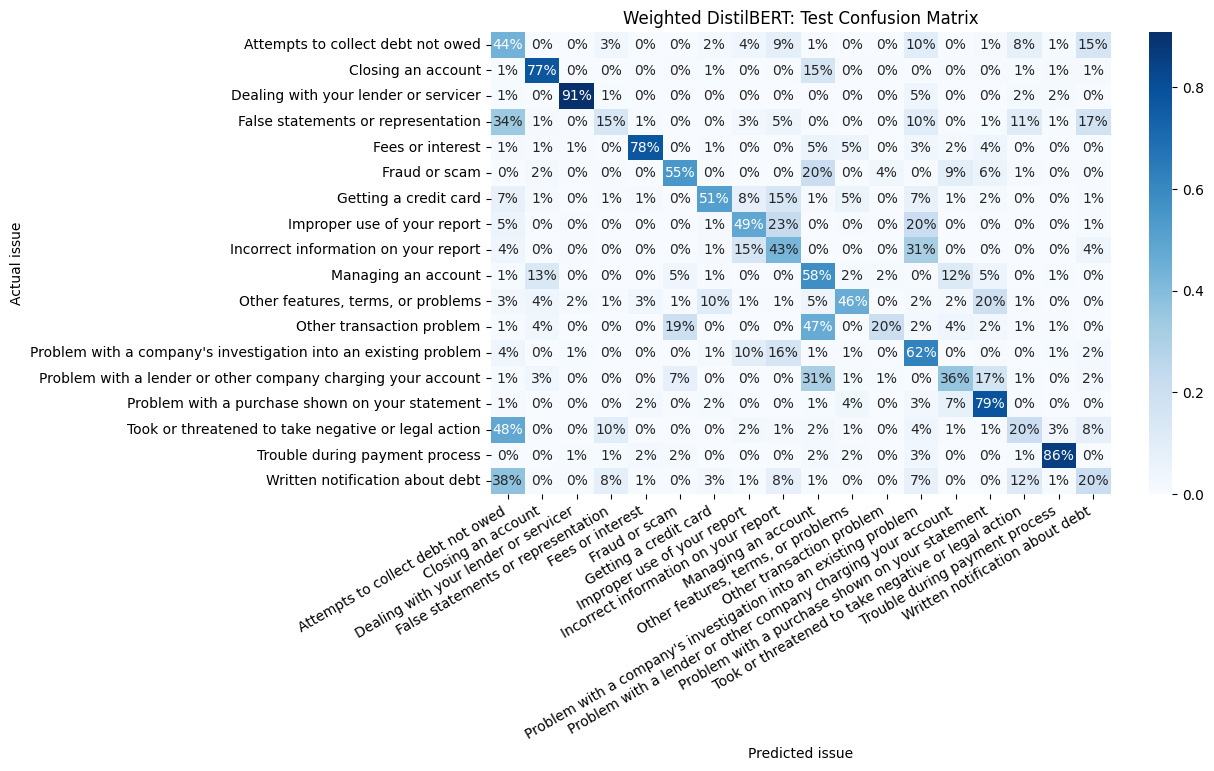

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

matrix = confusion_matrix(
    distilbert_test_labels,
    distilbert_test_predictions,
    normalize="true"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    matrix,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    fmt=".0%",
    annot=True
)

plt.title("Weighted DistilBERT: Test Confusion Matrix")
plt.xlabel("Predicted issue")
plt.ylabel("Actual issue")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.show()

Insight:

Each **row** in the confusion matrix shows the complaint’s actual CFPB issue. Each **column** shows the issue predicted by the model. The numbers are row percentages, so every row adds up to about 100%.

The dark diagonal cells show correct predictions. For example:

- **Dealing with your lender or servicer:** the model correctly routed **91%** of these complaints.
- **Fees or interest:** **78%** were correctly classified as fees or interest.
- **Trouble during payment process:** **86%** were correctly routed.

The off-diagonal cells show where the model gets confused:

- Of complaints actually labelled **Incorrect information on your report**, only **43%** were correctly identified. Another **31%** were predicted as **Problem with a company’s investigation into an existing problem**.
- Of complaints labelled **Written notification about debt**, only **20%** were correctly identified, while **38%** were predicted as **Attempts to collect debt not owed**.

This shows that the model handles specific operational problems well, but struggles when CFPB issue labels describe overlapping stages of the same credit-reporting or debt-collection problem.

STEP 29 — Try the final model on a new complaint

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    device=0,
    top_k=3
)

def predict_issue(complaint_text):
    predictions = classifier(
        complaint_text,
        truncation=True,
        max_length=512
    )

    #Access the inner list of predictions
    results = pd.DataFrame(predictions[0])

    results["score"] = (
        results["score"] * 100
    ).round(2)

    return results.rename(
        columns={
            "label": "Predicted issue",
            "score": "Confidence (%)"
        }
    )

new_complaint = """
My credit report contains an account that does not belong to me.
I disputed it, but the credit bureau has not corrected the information.
"""

display(predict_issue(new_complaint))

,Predicted issue,Confidence (%)
0,Written notification about debt,48.86
1,Problem with a company's investigation into an...,26.10
2,Attempts to collect debt not owed,10.92


Insight: This example also proves the review rule is useful:

It predicted Written notification about debt at only 48.86% confidence.
our complaint sounds closer to incorrect credit-report information, so the prediction is questionable.
Because it is below 60%, it would be sent for manual review rather than accepted automatically.

Try a clearer example next:

In [ ]:
new_complaint = """
I noticed a purchase on my credit card statement that I did not make.
Please remove this transaction and investigate it.
"""

display(predict_issue(new_complaint))

,Predicted issue,Confidence (%)
0,Problem with a purchase shown on your statement,78.13
1,Getting a credit card,5.10
2,Problem with a lender or other company chargin...,3.08


Problem with a purchase shown on our statement was predicted at 78.13%, far above the alternatives. It is a medium-confidence routing recommendation: strong enough to help an agent, but still appropriate to verify before a final action.

STEP 30 — Save the final model

In [ ]:
final_model_folder = "./ny_complaint_issue_router"

trainer.save_model(final_model_folder)
tokenizer.save_pretrained(final_model_folder)

print("Final model saved to:", final_model_folder)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to: ./ny_complaint_issue_router
